# Task 1 - Plan C Footfall Calibration

This notebook now shows **Plan C explicitly**.

Plan C is the delivered Task 1 estimate. It is saved as:

- `footfall_plan_c` in `outputs/task1_hourly_estimated_footfall.csv`
- `footfall_plan_c_trend_preserving` in `outputs/task1_hourly_estimated_footfall.csv`
- `pred_plan_c_trend_preserving` in `outputs/task1_calibration_windows.csv`

For compatibility, these are the same delivered values:

```text
footfall_plan_c == footfall_recommended == estimated_total_footfall
```

The old trusted-device linear model is kept only as a comparison because it validates well on four manual points but creates a flat hourly/daily trend through a large intercept.


## Plan C Plots Already Generated

These images are embedded directly from `outputs/plots/task1/plan_a/`, so you should see them immediately when you open the notebook.


### 1. Daily Totals: Plan C vs Old Trusted-Linear

![Plan C daily comparison](../outputs/plots/task1/plan_a/plan_c_daily_comparison.png)


### 2. Manual Calibration Windows

![Plan C calibration comparison](../outputs/plots/task1/plan_a/plan_c_calibration_windows.png)


### 3. Hourly Shape Check

![Plan C hourly shape](../outputs/plots/task1/plan_a/plan_c_hourly_shape.png)


### 4. Error Comparison

![Plan C model error comparison](../outputs/plots/task1/plan_a/plan_c_model_error_comparison.png)


## Load Plan C Tables

Run the cells below if you want to inspect the exact numbers behind the plots.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

from notebook_helpers import run_plan_a, plot_task1, show_task_plots, plot_footfall_dashboard_interactive

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# Recompute and write outputs so this notebook always reflects the latest Task 1 code.
plan_a = run_plan_a(force_recompute=True, write_outputs=True)
cal = plan_a["calibration"].copy()
hourly = plan_a["hourly"].copy()
model_comparison = plan_a["model_comparison"].copy()
loo = plan_a["leave_one_out"].copy()
bootstrap = plan_a["bootstrap"].copy()
task1_result = plan_a["task1_result"]

hourly["date"] = hourly["hour_start"].dt.date
cal["window_label"] = cal["facility_num"].astype(str) + " | " + cal["started"].dt.strftime("%Y-%m-%d %H:%M")

summary = pd.DataFrame([
    {"metric": "Plan C model", "value": task1_result.model_name},
    {"metric": "Plan C hourly column", "value": "footfall_plan_c"},
    {"metric": "Shape driver", "value": task1_result.feature_name},
    {"metric": "Elasticity beta", "value": task1_result.slope},
    {"metric": "Calibration MAPE", "value": f"{task1_result.mape * 100:.2f}%"},
    {"metric": "Leave-one-out MAPE", "value": f"{task1_result.loo_mape * 100:.2f}%"},
])
display(summary)


,metric,value
0,Plan C model,trend_clean_elasticity_beta_010
1,Plan C hourly column,footfall_plan_c
2,Shape driver,clean_unique_devices
3,Elasticity beta,0.100
4,Calibration MAPE,6.04%
5,Leave-one-out MAPE,12.16%


In [ ]:
# This should all be True.
checks = pd.DataFrame([
    {
        "check": "footfall_plan_c equals footfall_recommended",
        "value": bool((hourly["footfall_plan_c"].round(6) == hourly["footfall_recommended"].round(6)).all()),
    },
    {
        "check": "footfall_plan_c equals estimated_total_footfall",
        "value": bool((hourly["footfall_plan_c"].round(6) == hourly["estimated_total_footfall"].round(6)).all()),
    },
    {
        "check": "calibration has pred_plan_c_trend_preserving",
        "value": "pred_plan_c_trend_preserving" in cal.columns,
    },
])
display(checks)


## Calibration Table: Manual vs Plan C

This table is where Plan C directly compares against the manual count windows.


In [6]:
plan_c_calibration = cal[[
    "facility_num",
    "started",
    "manual_total_count",
    "pred_linear_trusted_unique_devices",
    "pred_plan_c_trend_preserving",
    "plan_c_abs_error",
    "plan_c_ape",
]].copy()
plan_c_calibration["plan_c_ape_pct"] = plan_c_calibration["plan_c_ape"] * 100
display(plan_c_calibration)


,facility_num,started,manual_total_count,pred_linear_trusted_unique_devices,pred_plan_c_trend_preserving,plan_c_abs_error,plan_c_ape,plan_c_ape_pct
0,66330,2026-04-23 13:00:00+00:00,651.000,639.150,611.440,39.560,0.061,6.077
1,66330,2026-04-24 13:00:00+00:00,550.000,559.270,587.410,37.410,0.068,6.802
2,66333,2026-04-23 15:00:00+00:00,565.000,542.820,527.100,37.900,0.067,6.708
3,66333,2026-04-24 15:00:00+00:00,558.000,582.760,583.500,25.500,0.046,4.570


## Daily Table: Old Model vs Plan C

This is the clearest table for seeing that Plan C is not the old flat trusted-device output.


In [7]:
plan_c_daily = hourly.groupby("date", as_index=False)[[
    "footfall_trusted_linear",
    "footfall_plan_c",
    "footfall_clean_capture_shrunk",
    "clean_unique_devices",
    "trusted_unique_devices",
]].sum()
plan_c_daily["plan_c_minus_old_trusted"] = plan_c_daily["footfall_plan_c"] - plan_c_daily["footfall_trusted_linear"]
plan_c_daily["plan_c_index"] = plan_c_daily["footfall_plan_c"] / plan_c_daily["footfall_plan_c"].mean()
display(plan_c_daily)


,date,footfall_trusted_linear,footfall_plan_c,footfall_clean_capture_shrunk,clean_unique_devices,trusted_unique_devices,plan_c_minus_old_trusted,plan_c_index
0,2026-04-20,"110,340.730","97,453.780","74,278.330","269,455.000","2,296.000","-12,886.950",0.965
1,2026-04-21,"112,108.210","91,470.950","42,640.430","169,143.000","1,728.000","-20,637.260",0.905
2,2026-04-22,"113,679.910","99,979.640","76,807.140","275,816.000","2,397.000","-13,700.270",0.990
3,2026-04-23,"110,989.300","90,914.000","67,717.600","249,828.000","2,572.000","-20,075.300",0.900
4,2026-04-24,"116,607.370","106,925.190","93,899.470","337,451.000","3,423.000","-9,682.180",1.058
5,2026-04-25,"114,715.540","109,576.510","143,231.400","508,375.000","3,718.000","-5,139.030",1.085
6,2026-04-26,"117,622.500","110,890.140","116,039.260","421,758.000","3,415.000","-6,732.360",1.098


## Recreate The Plan C Plots In The Notebook

These cells redraw the same plots inside the notebook output area.


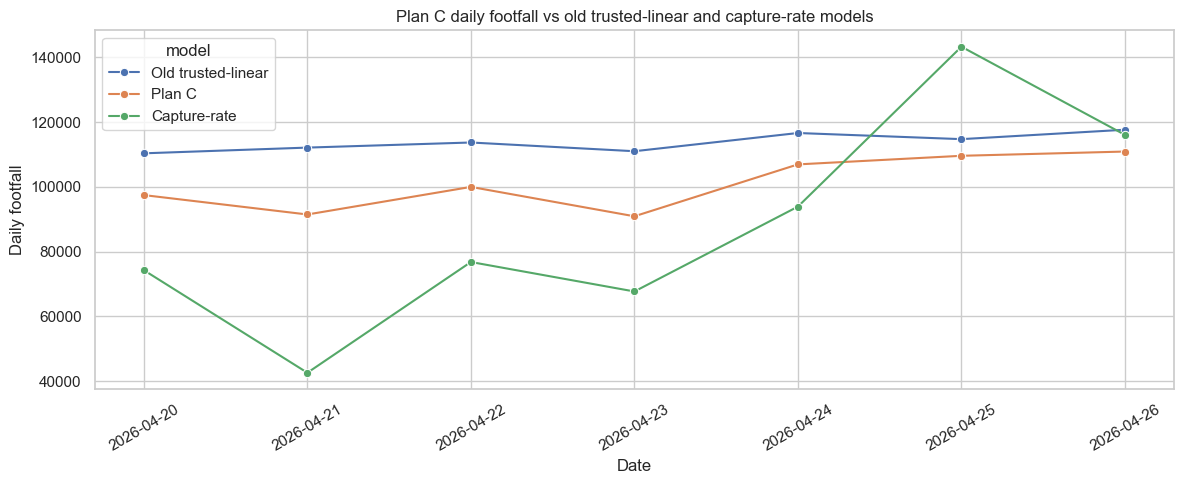

In [8]:
plot_daily = plan_c_daily.rename(columns={
    "footfall_trusted_linear": "Old trusted-linear",
    "footfall_plan_c": "Plan C",
    "footfall_clean_capture_shrunk": "Capture-rate",
}).melt(
    id_vars="date",
    value_vars=["Old trusted-linear", "Plan C", "Capture-rate"],
    var_name="model",
    value_name="daily_footfall",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=plot_daily, x="date", y="daily_footfall", hue="model", marker="o", ax=ax)
ax.set_title("Plan C daily footfall vs old trusted-linear and capture-rate models")
ax.set_xlabel("Date")
ax.set_ylabel("Daily footfall")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


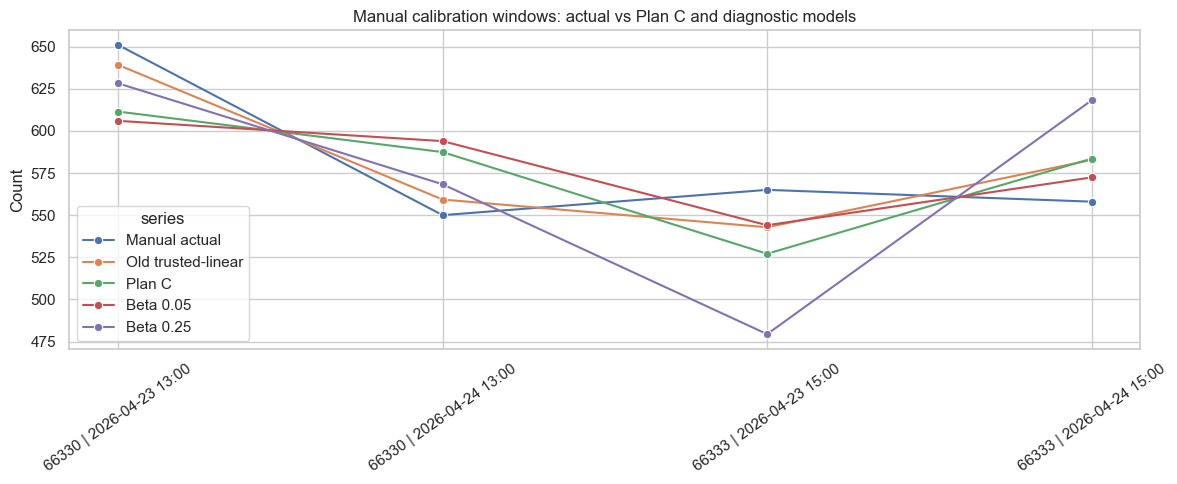

In [9]:
cal_plot = cal.rename(columns={
    "manual_total_count": "Manual actual",
    "pred_linear_trusted_unique_devices": "Old trusted-linear",
    "pred_plan_c_trend_preserving": "Plan C",
    "pred_trend_clean_elasticity_beta_005": "Beta 0.05",
    "pred_trend_clean_elasticity_beta_025": "Beta 0.25",
}).copy()

plot_cal = cal_plot.melt(
    id_vars="window_label",
    value_vars=["Manual actual", "Old trusted-linear", "Plan C", "Beta 0.05", "Beta 0.25"],
    var_name="series",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=plot_cal, x="window_label", y="count", hue="series", marker="o", ax=ax)
ax.set_title("Manual calibration windows: actual vs Plan C and diagnostic models")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


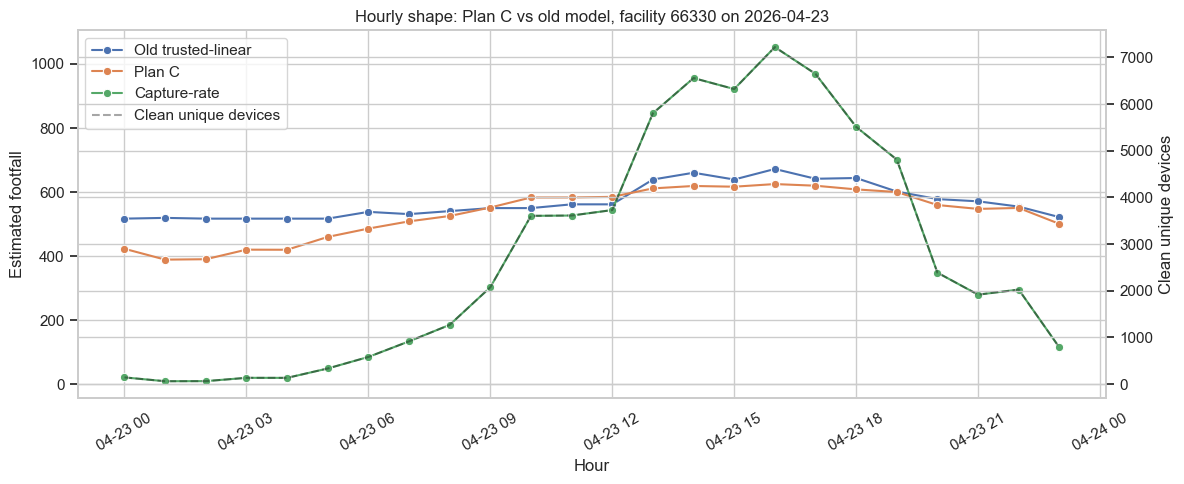

In [10]:
focus_facility = int(cal["facility_num"].iloc[0])
focus_date = cal.loc[cal["facility_num"] == focus_facility, "started"].dt.date.iloc[0]
focus = hourly[(hourly["facility_num"] == focus_facility) & (hourly["date"] == focus_date)].copy()

plot_hourly = focus.rename(columns={
    "footfall_trusted_linear": "Old trusted-linear",
    "footfall_plan_c": "Plan C",
    "footfall_clean_capture_shrunk": "Capture-rate",
}).melt(
    id_vars="hour_start",
    value_vars=["Old trusted-linear", "Plan C", "Capture-rate"],
    var_name="model",
    value_name="hourly_footfall",
)

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=plot_hourly, x="hour_start", y="hourly_footfall", hue="model", marker="o", ax=ax1)
ax1.set_title(f"Hourly shape: Plan C vs old model, facility {focus_facility} on {focus_date}")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Estimated footfall")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(focus["hour_start"], focus["clean_unique_devices"], color="black", linestyle="--", alpha=0.35, label="Clean unique devices")
ax2.set_ylabel("Clean unique devices")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()


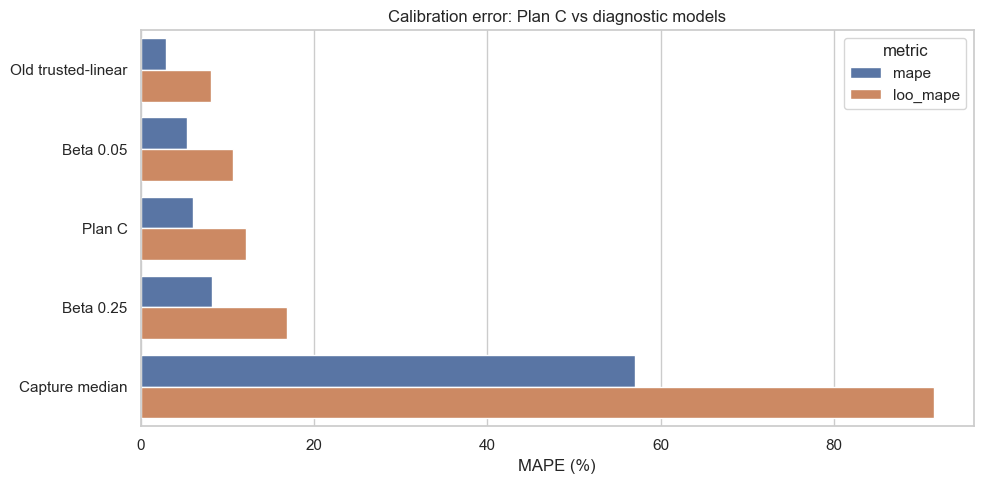

,model_label,model_name,mape,loo_mape,selected_for_delivery,selection_note
0,Old trusted-linear,linear_trusted_unique_devices,0.030,0.082,False,Diagnostic comparison model
6,Beta 0.05,trend_clean_elasticity_beta_005,0.053,0.106,False,Diagnostic comparison model
7,Plan C,trend_clean_elasticity_beta_010,0.060,0.122,True,Plan C delivered estimate: preserves clean-dev...
8,Beta 0.25,trend_clean_elasticity_beta_025,0.082,0.169,False,Diagnostic comparison model
27,Capture median,capture_median_clean_unique_devices,0.571,0.916,False,Diagnostic comparison model


In [11]:
models = [
    "linear_trusted_unique_devices",
    "trend_clean_elasticity_beta_005",
    "trend_clean_elasticity_beta_010",
    "trend_clean_elasticity_beta_025",
    "capture_median_clean_unique_devices",
]
error_view = model_comparison.loc[model_comparison["model_name"].isin(models)].copy()
error_view["model_label"] = error_view["model_name"].replace({
    "linear_trusted_unique_devices": "Old trusted-linear",
    "trend_clean_elasticity_beta_005": "Beta 0.05",
    "trend_clean_elasticity_beta_010": "Plan C",
    "trend_clean_elasticity_beta_025": "Beta 0.25",
    "capture_median_clean_unique_devices": "Capture median",
})
error_plot = error_view.melt(
    id_vars="model_label",
    value_vars=["mape", "loo_mape"],
    var_name="metric",
    value_name="error_pct",
)
error_plot["error_pct"] *= 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=error_plot, y="model_label", x="error_pct", hue="metric", ax=ax)
ax.set_title("Calibration error: Plan C vs diagnostic models")
ax.set_xlabel("MAPE (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(error_view[["model_label", "model_name", "mape", "loo_mape", "selected_for_delivery", "selection_note"]])


## Existing Project Plots

These are the original Task 1 helper plots. They are still useful, but the Plan C plots above are the new explicit comparison views.


In [12]:
plot_dirs = plot_task1(plan="a")
plot_dirs


{'plan_a': PosixPath('/Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task1/plan_a')}

15 plots in /Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task1/plan_a
footfall_daily_by_facility_heatmap.png


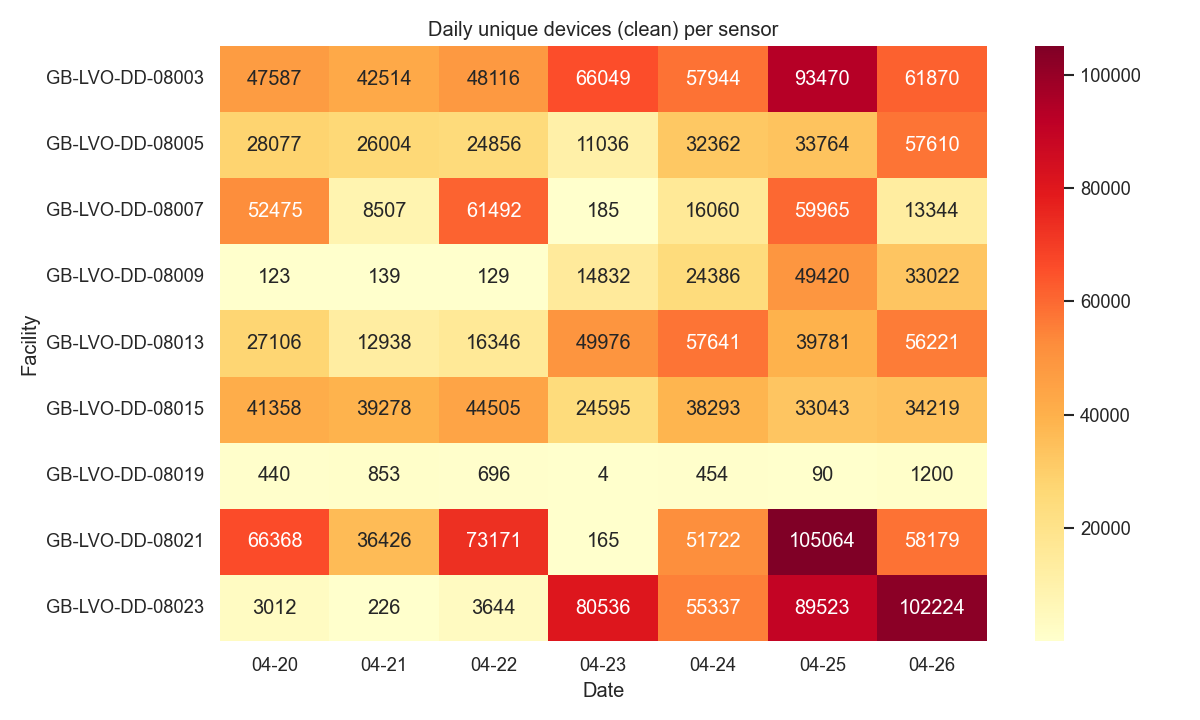

footfall_daily_device_types_stacked.png


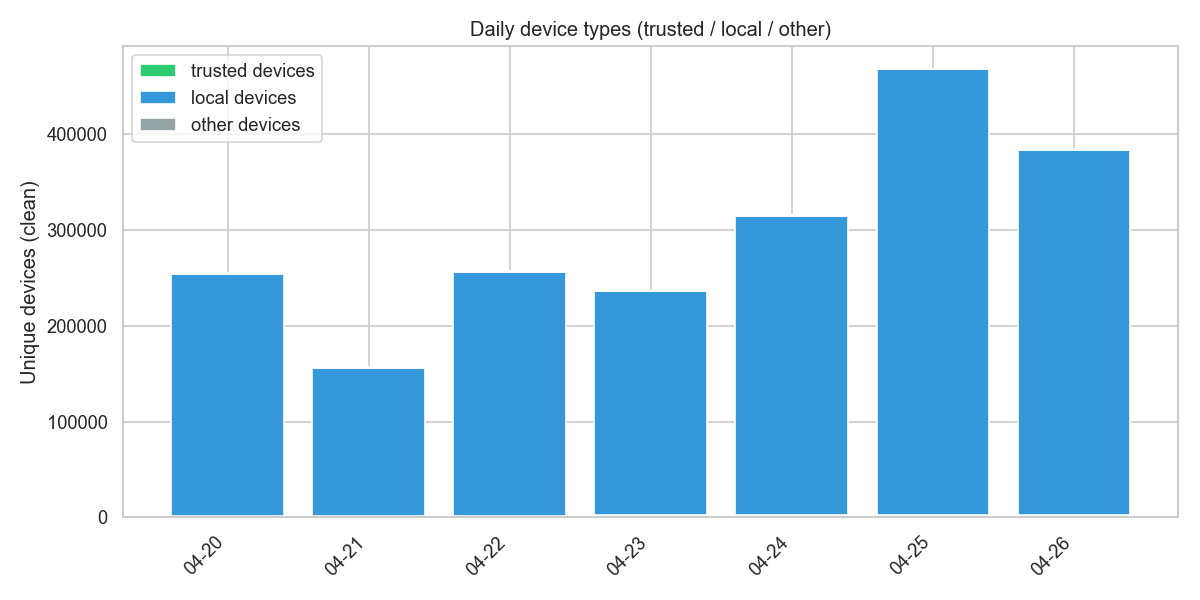

footfall_daily_estimated_vs_detected.png


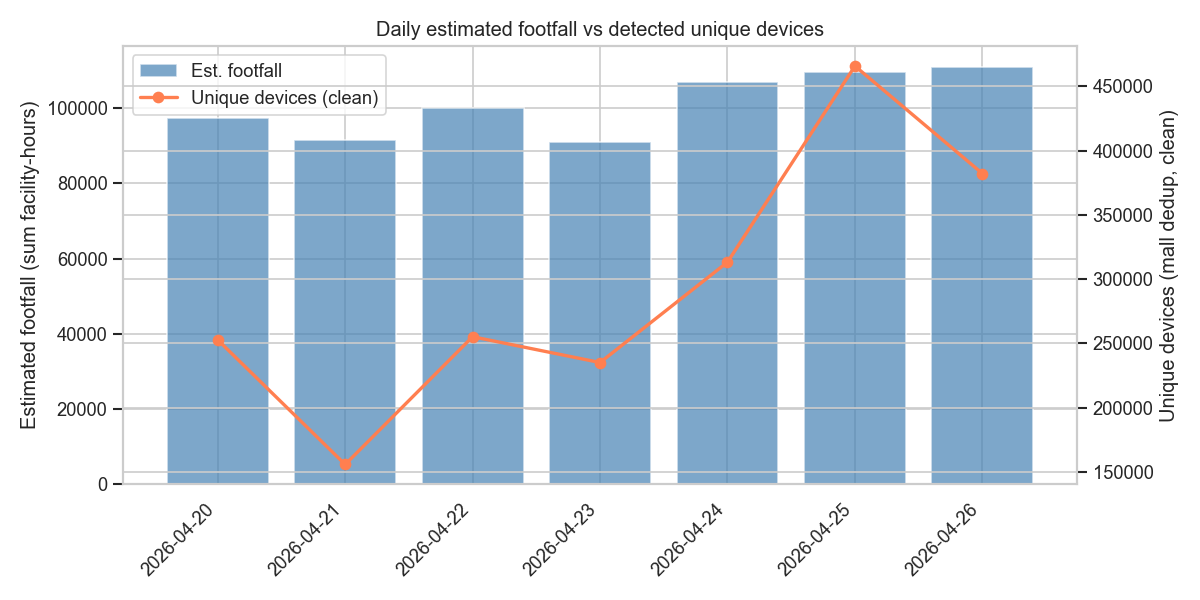

footfall_daily_sessions_and_devices.png


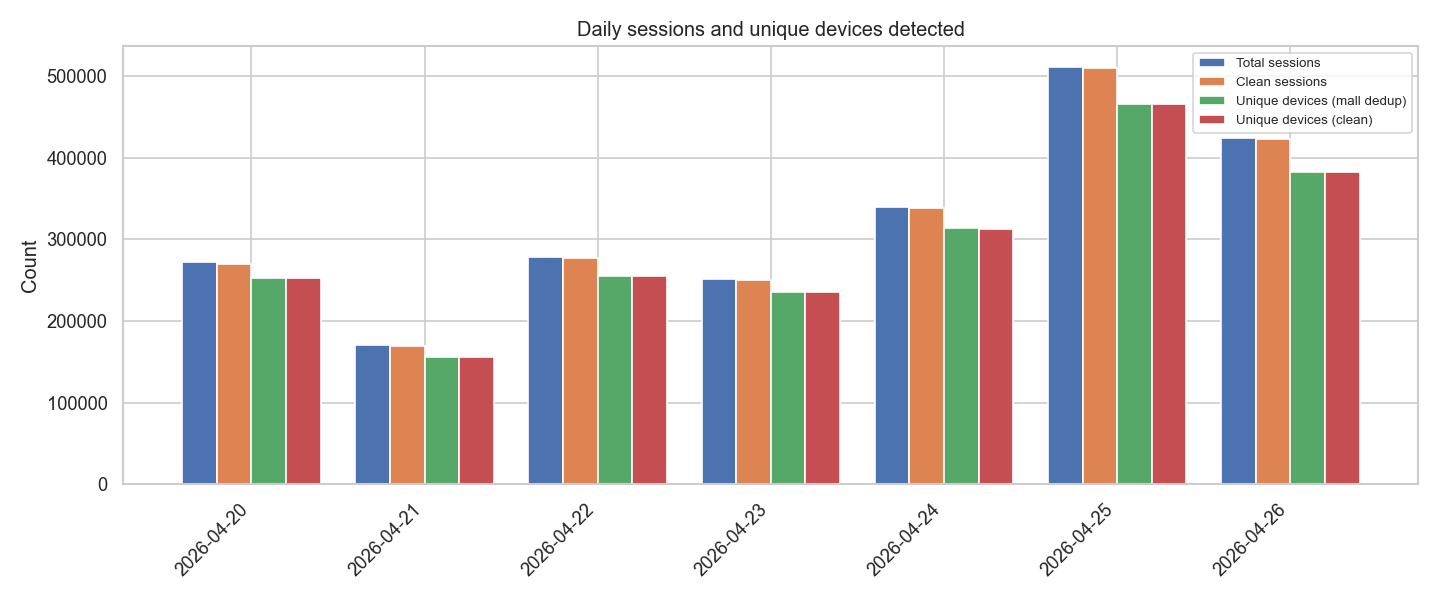

footfall_manual_calibration_overlay.png


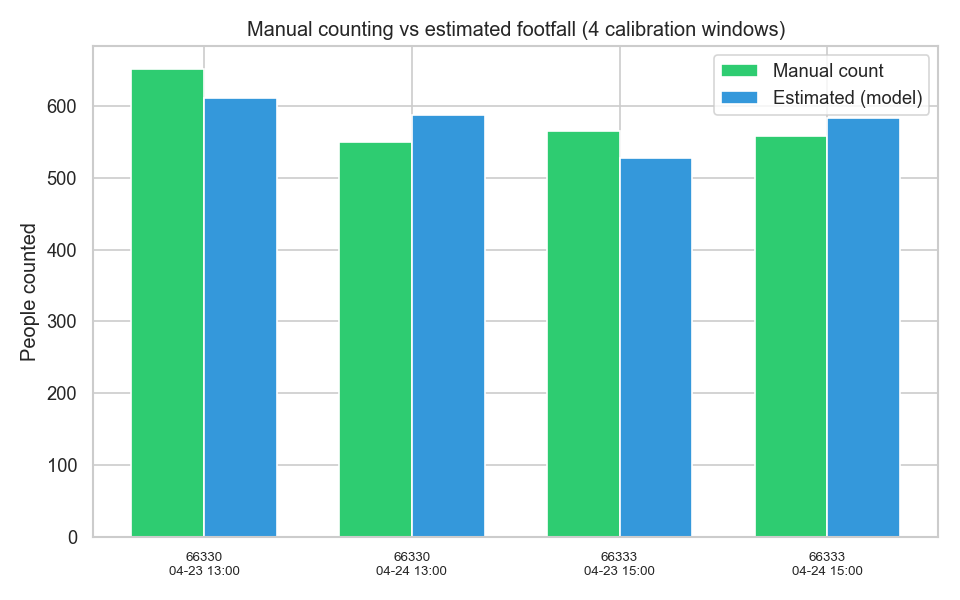

footfall_weekly_totals.png


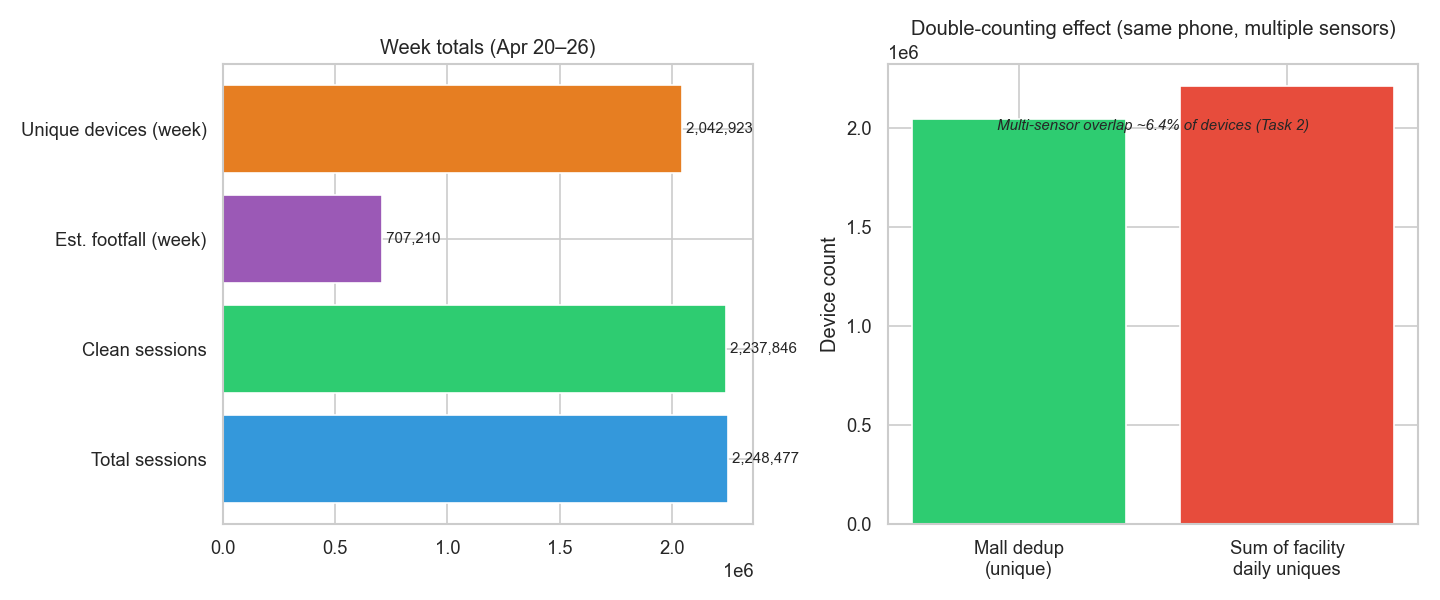

manual_calibration_overlay.png


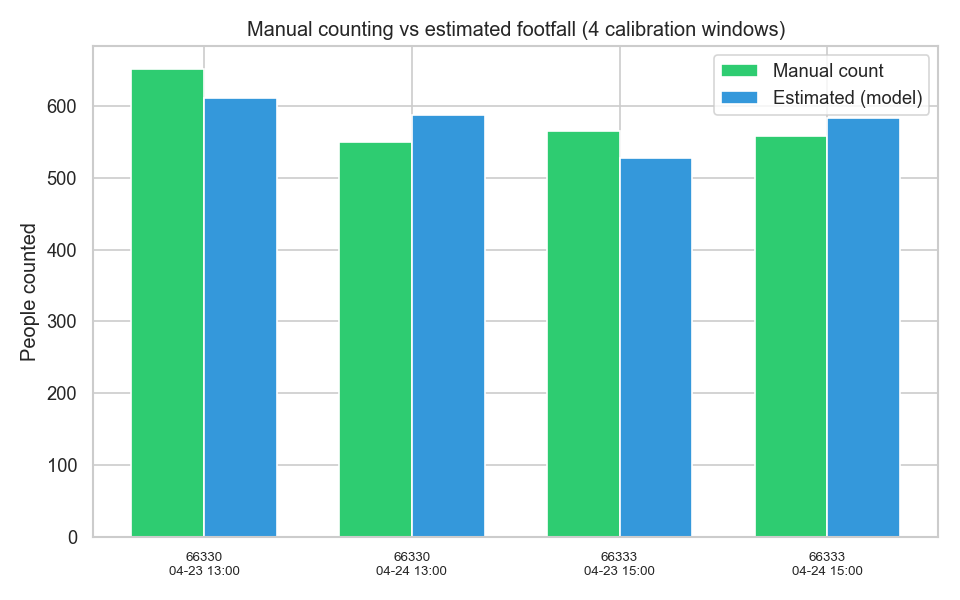

plan_a_all_facilities_daily_footfall_bars.png


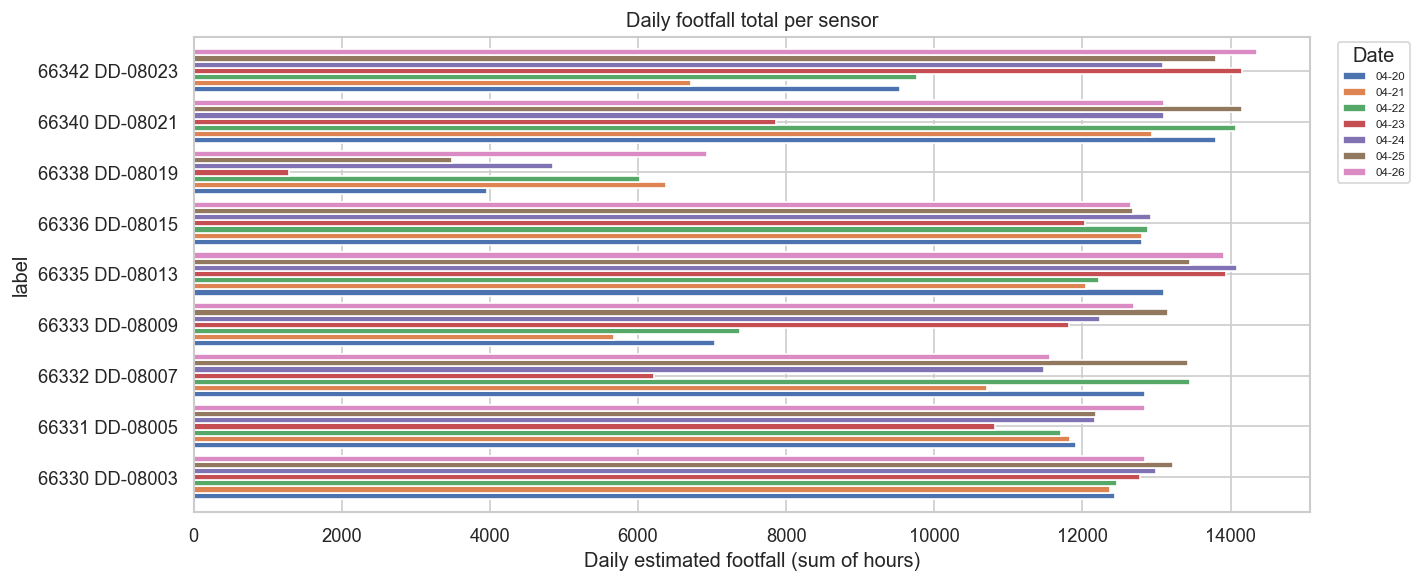

plan_a_all_facilities_daily_footfall_heatmap.png


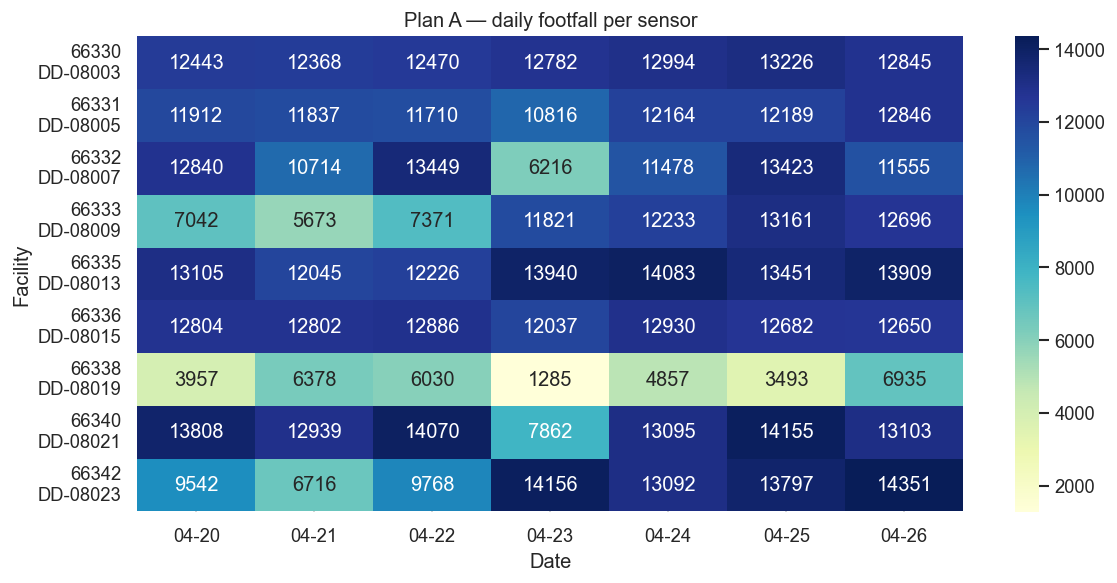

plan_a_all_facilities_hourly_devices.png


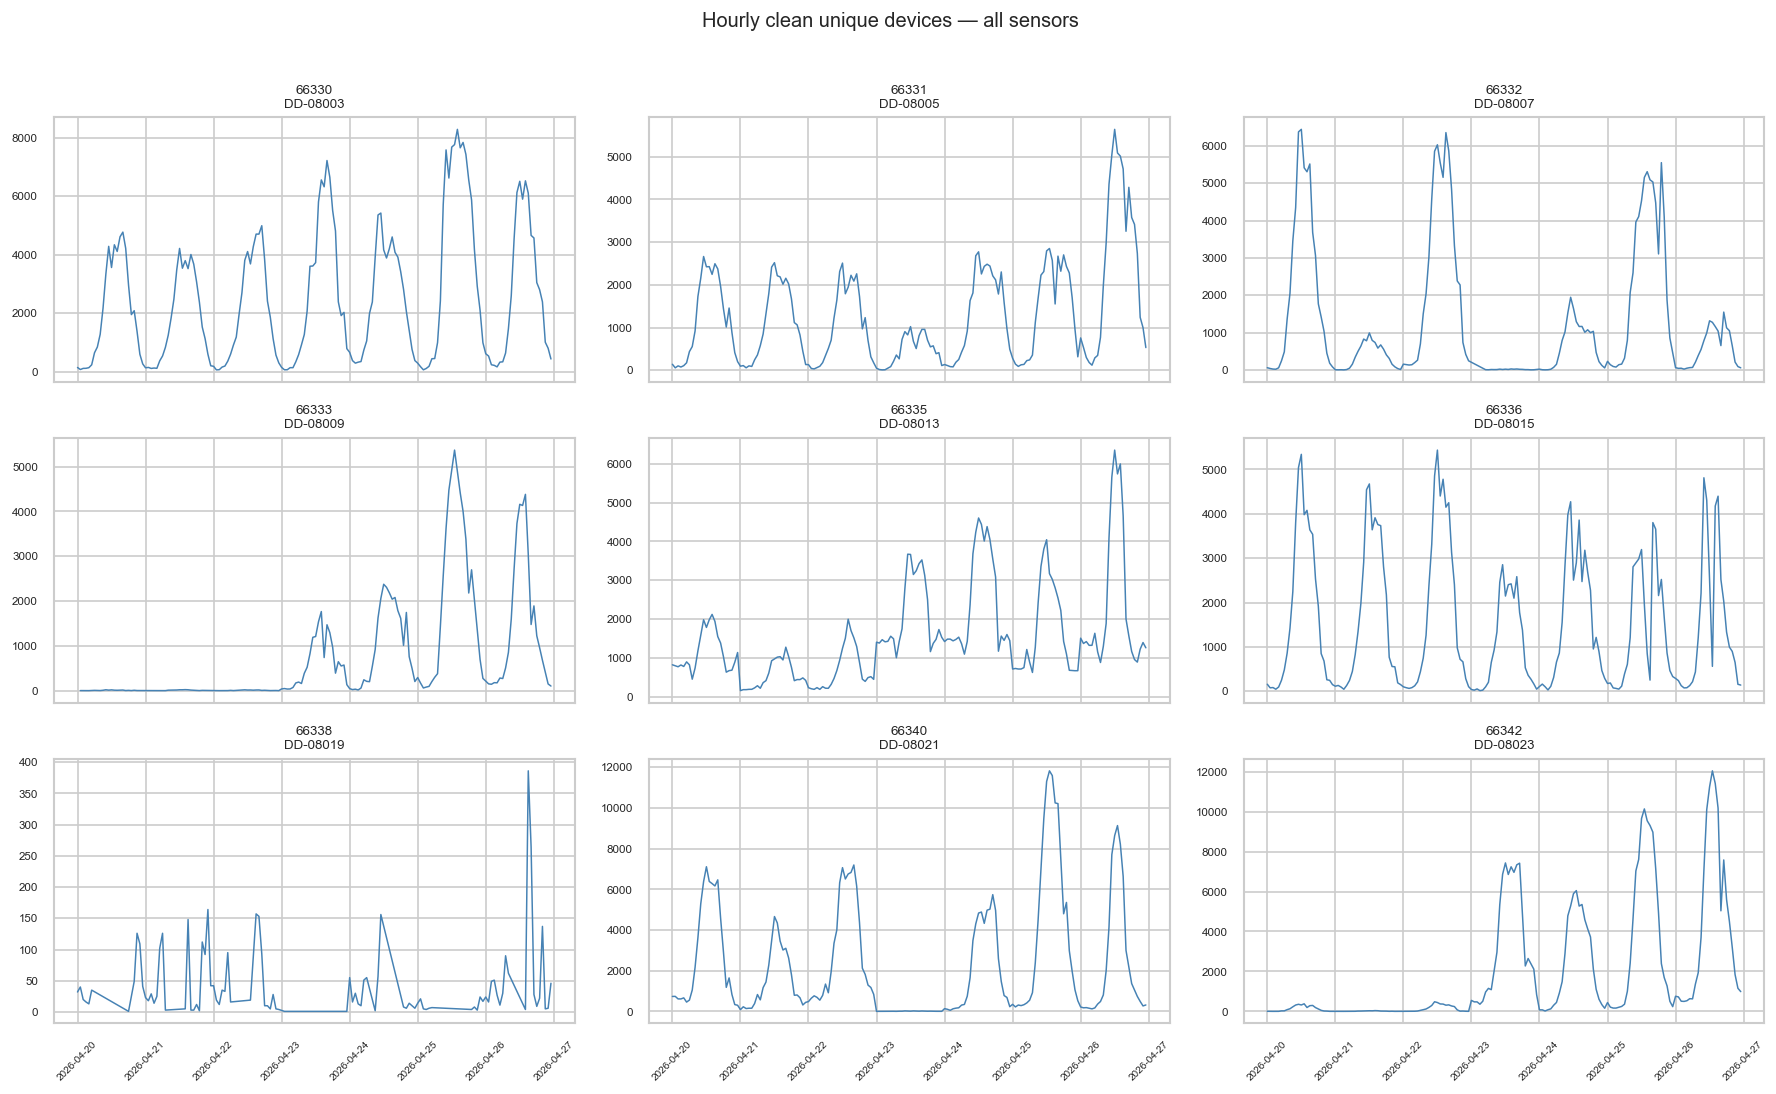

plan_a_all_facilities_hourly_footfall.png


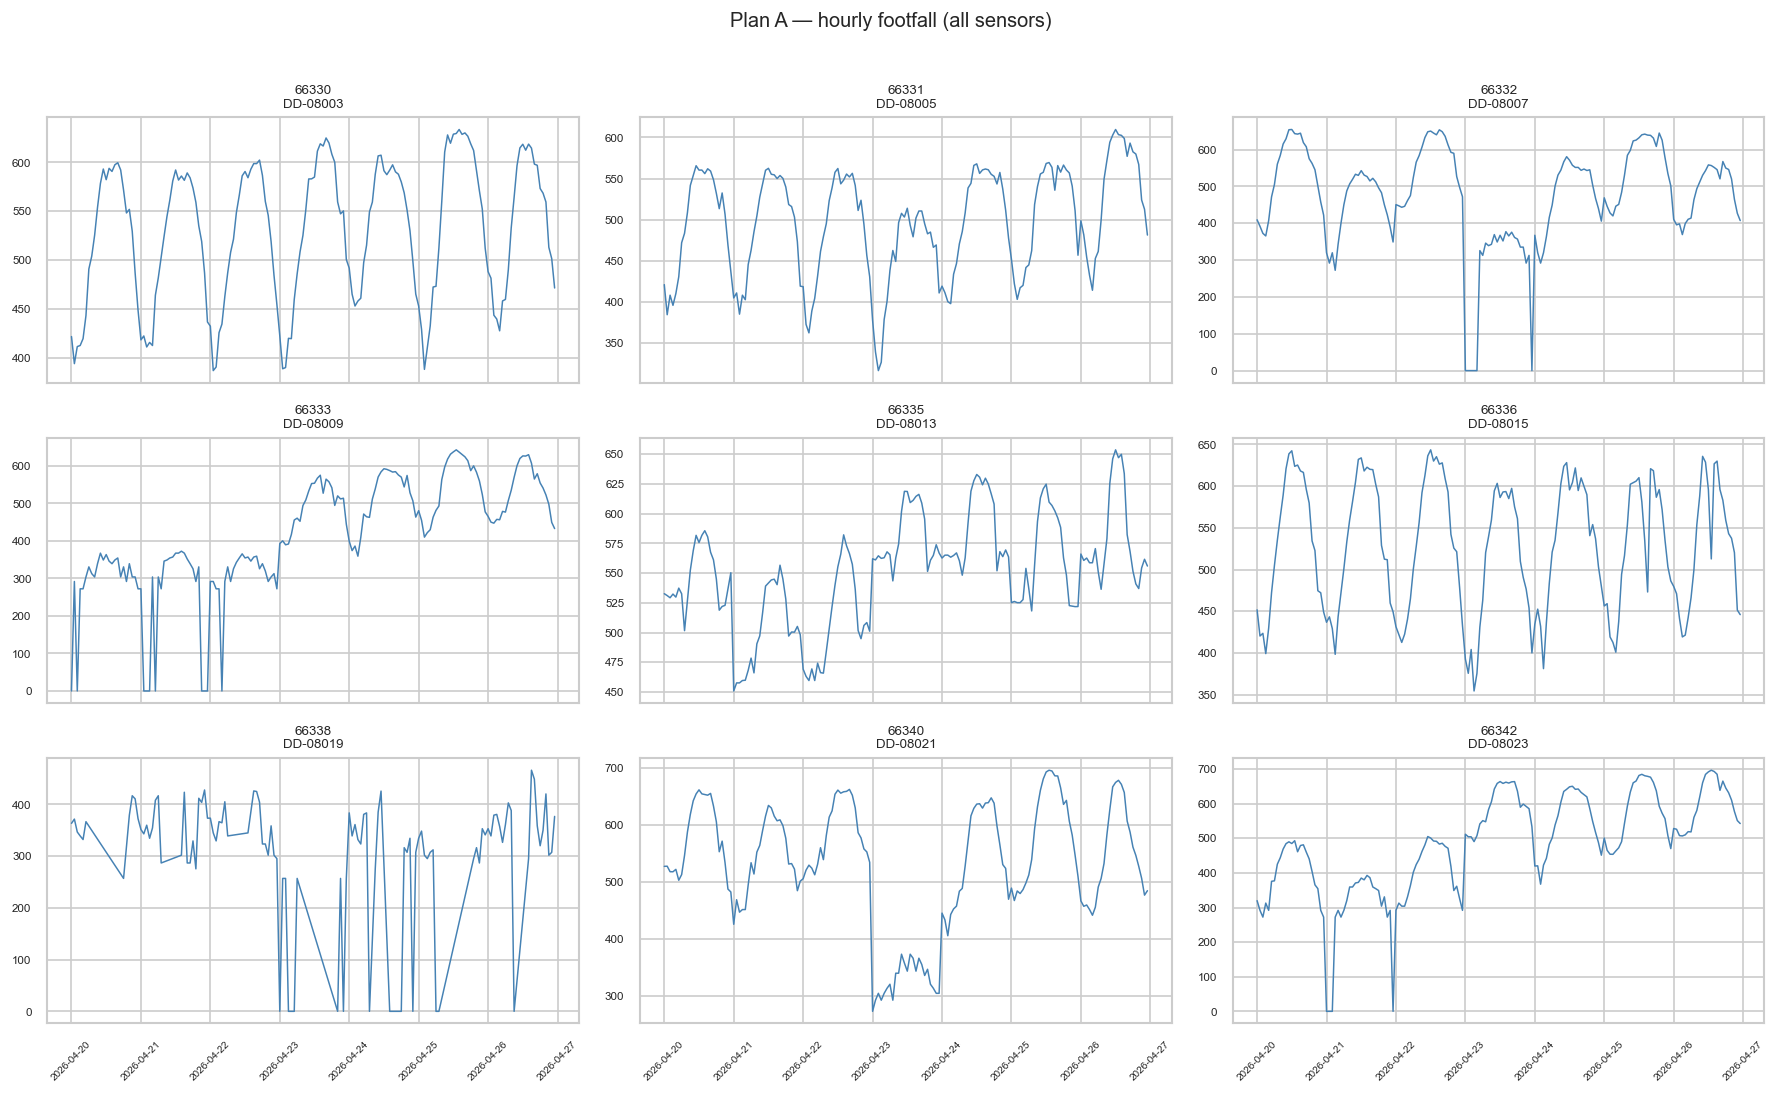

plan_c_calibration_windows.png


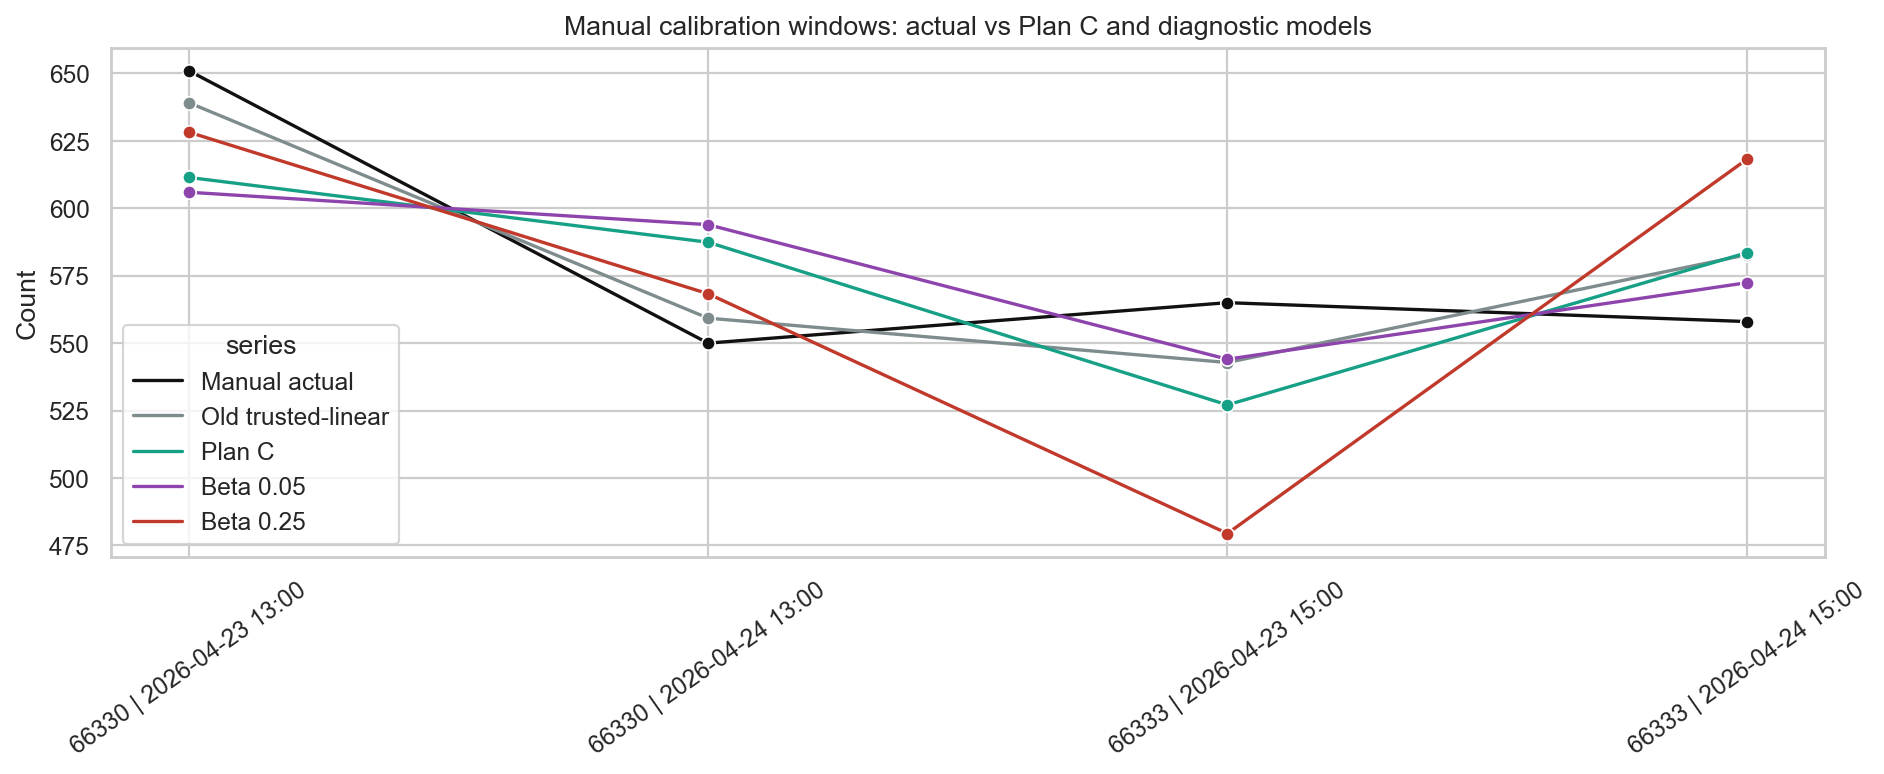

plan_c_daily_comparison.png


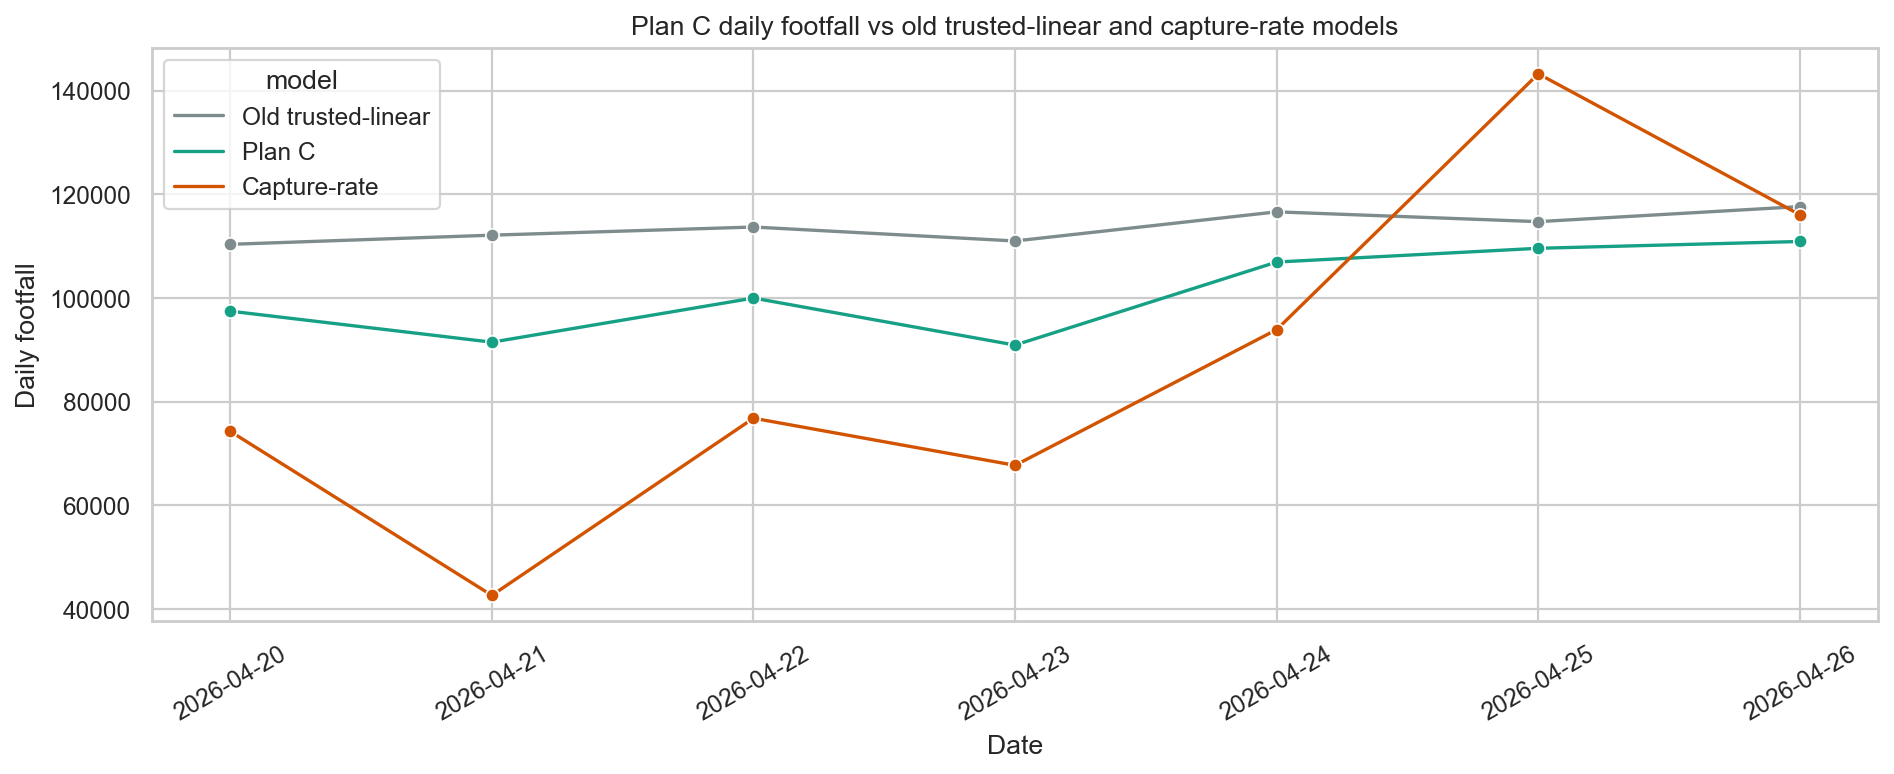

plan_c_hourly_shape.png


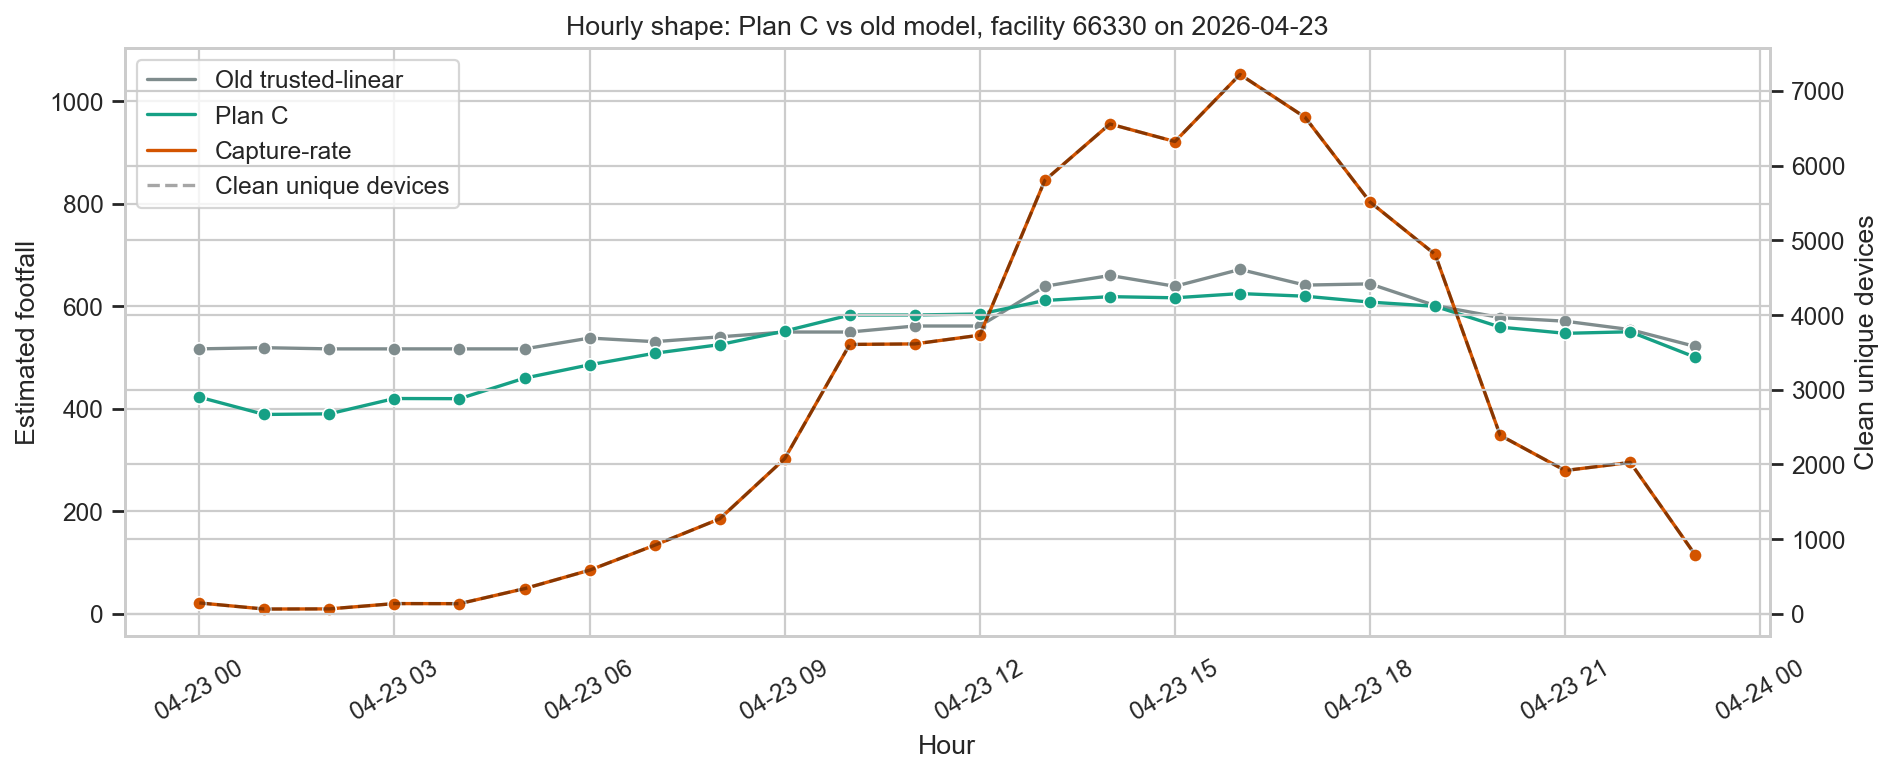

plan_c_model_error_comparison.png


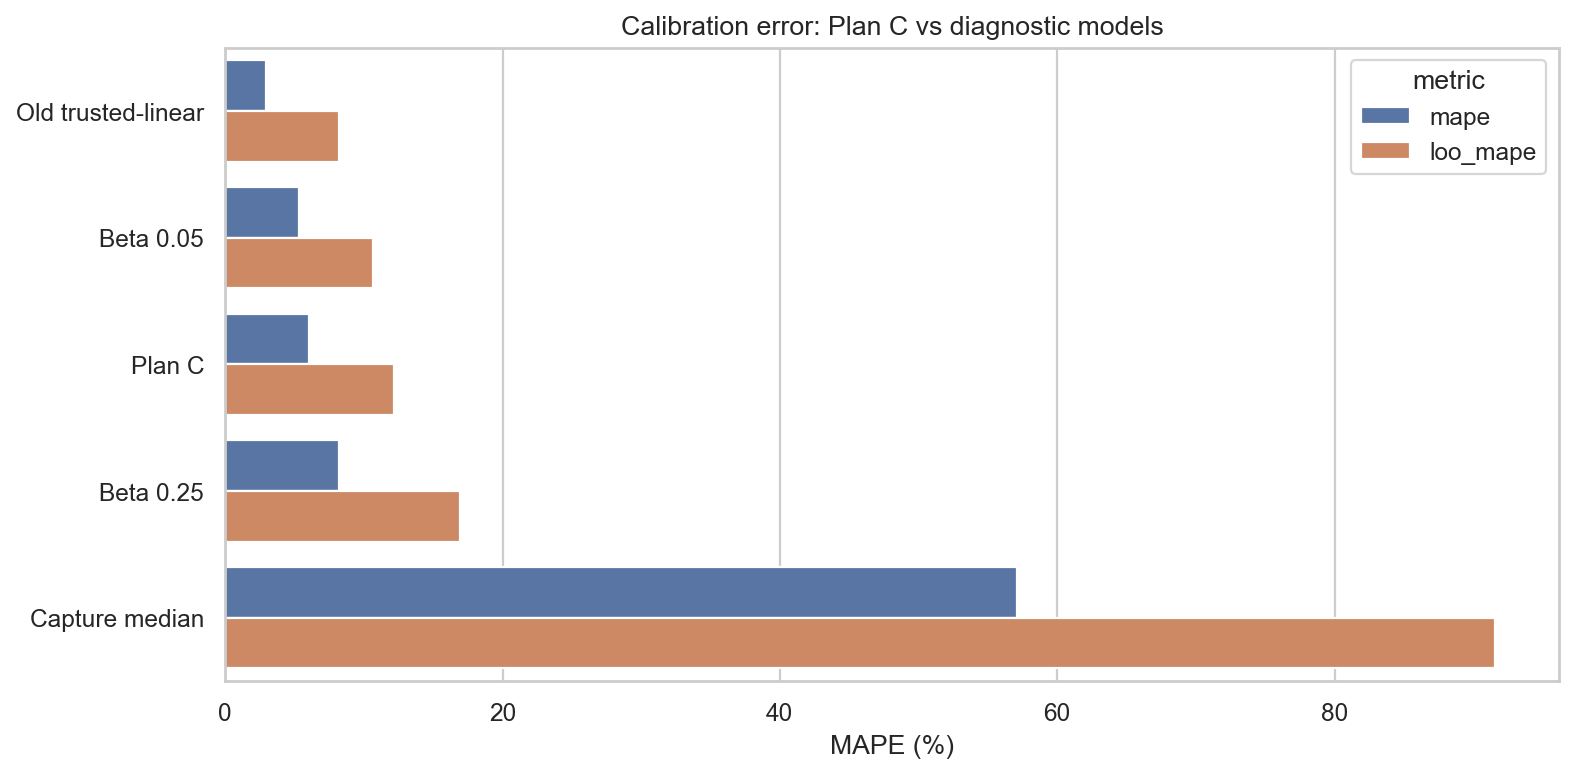

In [13]:
show_task_plots(1, plan="a")


## Optional Interactive Dashboard

Run this manually if you want the broader interactive dashboard.


In [ ]:
plot_footfall_dashboard_interactive()
